## 画像マスの抽出

In [1]:
import cv2
filename = "../data/level1/sample.jpg"
img = cv2.imread(filename, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("FaileRd to load image: {:s}".format(filename))

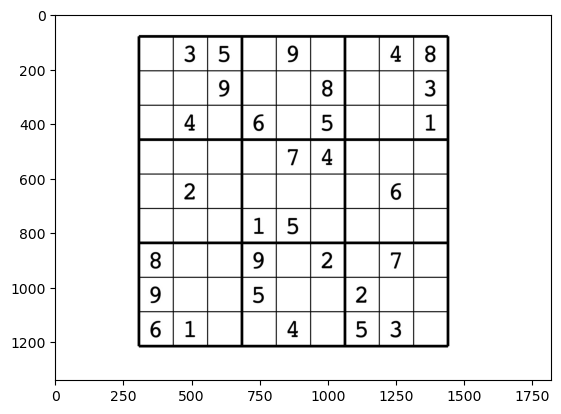

In [7]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [2]:
import cv2
import numpy as np

# 二値データに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 9x9の格子の外枠を見つける（最も大きな輪郭と想定）
largest_contour = max(contours, key=cv2.contourArea)

# マス目の輪郭の四角を描く
x, y, w, h = cv2.boundingRect(largest_contour)

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9
stepy = h // 9
for i in range(9):
    for j in range(9):
        cell = img[y + j*stepy:y + (j+1)*stepy, x + i*stepx:x + (i+1)*stepx]
        cell_images.append(cell)

# 例として、抽出したマス目の画像を保存
for idx, cell in enumerate(cell_images):
    cv2.imwrite(f"cell_{idx}.png", cell)


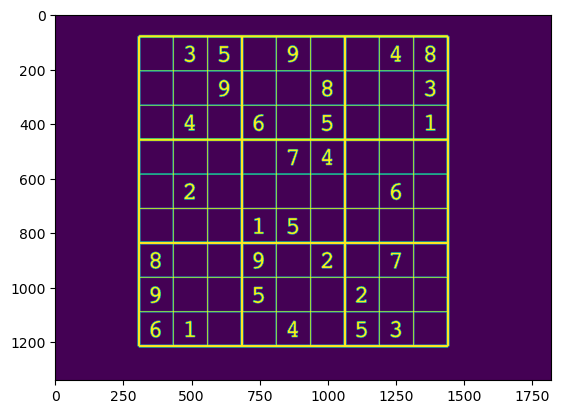

In [27]:
plt.imshow(thresh)
plt.show()

# 数字の識別

In [14]:
# データ読み込み
import numpy as np
from sklearn import svm
photos = np.load('../data/samples/28px_10-2.npz')
x = photos['x']/255
y = photos['y']
print(x.shape)
print(y.shape)

# SVMで学習
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=1)
clf = svm.SVC()
clf.fit(X_train, y_train)

(1560, 784)
(1560,)


SVC()

In [15]:
from sklearn import metrics

# 予測の実行
predicted = clf.predict(X_test)
print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")


Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        26
           1       0.97      0.95      0.96        37
           2       0.89      1.00      0.94        24
           3       0.97      0.88      0.92        32
           4       0.97      0.94      0.95        32
           5       0.77      0.74      0.75        31
           6       0.78      0.86      0.82        29
           7       0.91      0.97      0.94        31
           8       0.88      0.81      0.85        37
           9       0.85      0.88      0.87        33

    accuracy                           0.89       312
   macro avg       0.89      0.90      0.90       312
weighted avg       0.90      0.89      0.89       312


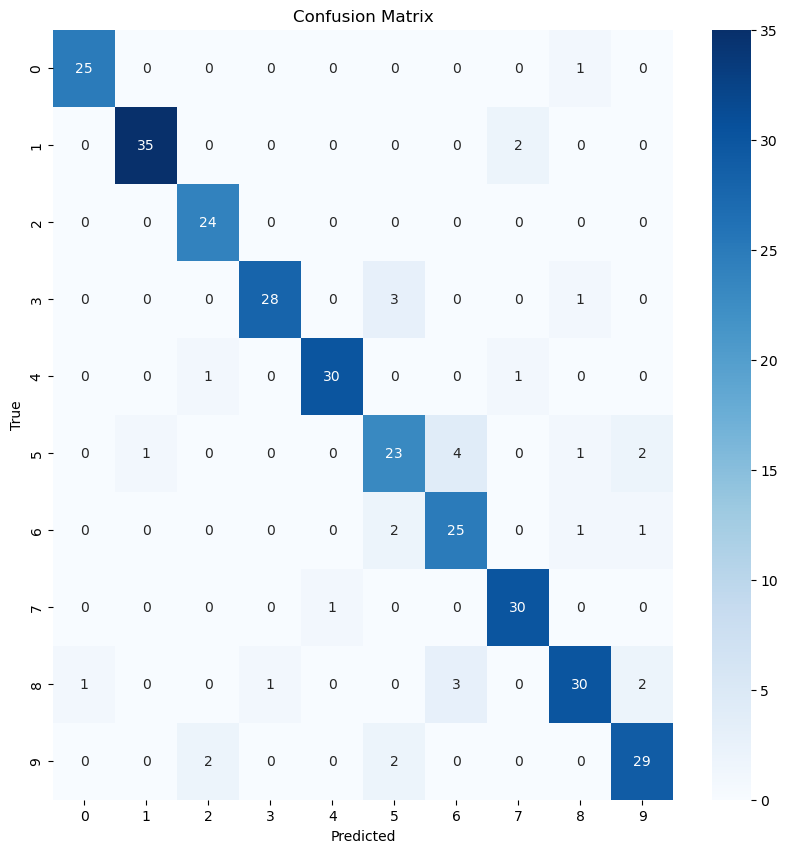

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 混同行列の可視化
conf_mat = metrics.confusion_matrix(y_test, predicted)
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
